# Online Learning / Fine-Tuning bằng Gradient Descent

Notebook này mô phỏng kịch bản Học liên tục (Online Learning). Để chống lại hiện tượng Overreacting (học sai do dữ liệu nhiễu ngoại lai), mô hình đã được trang bị 2 kỹ thuật tối tân: **L2 Regularization** và **Gradient Clipping**.

In [1]:
import pandas as pd
import numpy as np
import sys
import os
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

# Thiết lập đường dẫn động
current_dir = os.getcwd()
if os.path.basename(current_dir) == 'notebooks':
    project_root = os.path.abspath(os.path.join(current_dir, '..'))
else:
    project_root = current_dir
src_path = os.path.join(project_root, 'src')
sys.path.insert(0, project_root)

from src.models.preprocessing import time_series_split, StandardScaler
from src.models.linear_regression_gd import LinearRegressionGD
from features.build_features import extract_date_features

print("Modules loaded successfully.")

Modules loaded successfully.


### 1. Nạp và Xử lý dữ liệu Chuỗi thời gian

In [2]:
data_path = os.path.join(project_root, 'data', 'raw', 'ecommerce_dataset_updated.csv')
df_raw = pd.read_csv(data_path)
df_raw['Purchase_Date'] = pd.to_datetime(df_raw['Purchase_Date'], format='%d-%m-%Y', dayfirst=True)
df_daily = df_raw.groupby('Purchase_Date').size().reset_index(name='Daily_Volume')
df_daily = df_daily.sort_values(by='Purchase_Date').reset_index(drop=True)

df_daily['Purchase_Date_Str'] = df_daily['Purchase_Date'].dt.strftime('%d-%m-%Y')
df_features = extract_date_features(df_daily, date_column='Purchase_Date_Str')
df_features = df_features.drop(columns=['Purchase_Date', 'Purchase_Date_Str'])

target_col = 'Daily_Volume'
X = df_features.drop(columns=[target_col])
y = df_features[target_col]

X_train, X_test, y_train, y_test = time_series_split(X, y, test_size=0.2)

scaler = StandardScaler()
numeric_cols = ['Purchase_Year', 'Purchase_Month', 'Purchase_Day', 'Purchase_DayOfWeek']

X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

scaler.fit(X_train[numeric_cols])
X_train_scaled[numeric_cols] = scaler.transform(X_train[numeric_cols])
X_test_scaled[numeric_cols] = scaler.transform(X_test[numeric_cols])

### 2. Huấn luyện Mô hình Khởi điểm (Offline Training)
Lần này ta áp dụng L2 Regularization (alpha) và Gradient Clipping (clip_value).

In [3]:
from copy import deepcopy

# Khởi tạo Gradient Descent với các "tấm khiên" bảo vệ chống Overfitting
base_model = LinearRegressionGD(learning_rate=0.01, epochs=1000, alpha=0.5, clip_value=1.0)
base_model.fit(X_train_scaled, y_train)

static_model = deepcopy(base_model)
online_model = deepcopy(base_model)

print("Đã huấn luyện xong mô hình khởi điểm!")

Đã huấn luyện xong mô hình khởi điểm!


### 3. Kịch bản Thời gian Thực (Online Learning)

In [4]:
static_predictions = []
online_predictions = []
actuals = y_test.values

for i in range(len(X_test_scaled)):
    x_today = X_test_scaled.iloc[[i]]
    y_today_actual = pd.Series([actuals[i]])
    
    static_pred = static_model.predict(x_today)[0]
    online_pred = online_model.predict(x_today)[0]
    
    static_predictions.append(static_pred)
    online_predictions.append(online_pred)
    
    # Dù hôm nay có dữ liệu ngoại lai, Gradient Clipping sẽ không cho phép Weights bị lệch quá nhiều.
    online_model.partial_fit(x_today, y_today_actual, epochs=2)

print("Đã hoàn tất mô phỏng Online Learning!")

Đã hoàn tất mô phỏng Online Learning!


### 4. Đánh giá kết quả sau khi được tối ưu

MAE Mô hình Tĩnh: 2.46 | RMSE: 3.17
MAE Mô hình Động: 2.46 | RMSE: 3.11


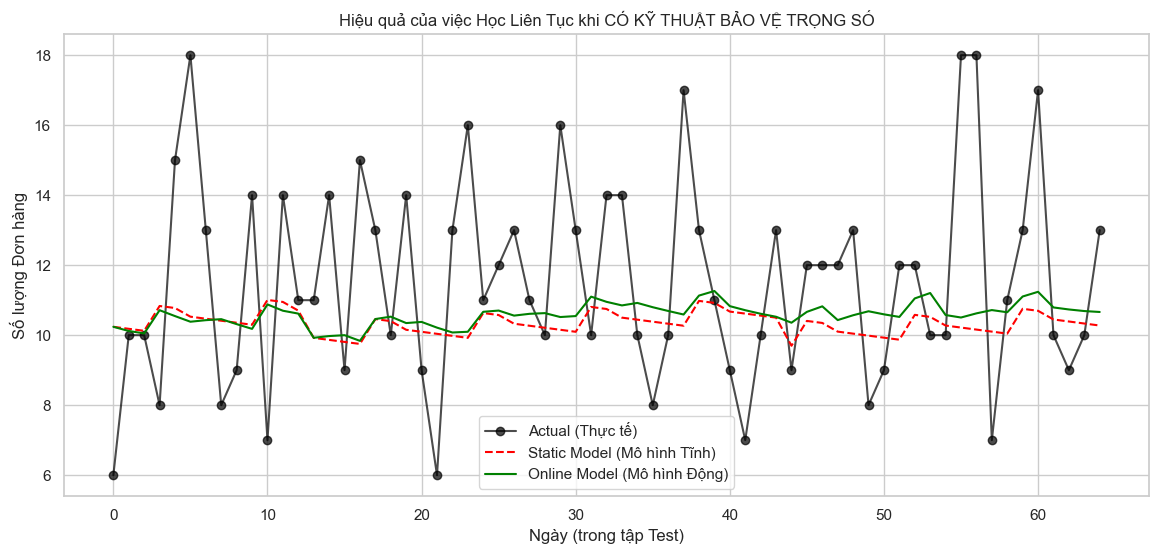

In [5]:
from src.models.metrics import mean_absolute_error, root_mean_squared_error

mae_static = mean_absolute_error(pd.Series(actuals), pd.Series(static_predictions))
mae_online = mean_absolute_error(pd.Series(actuals), pd.Series(online_predictions))
rmse_static = root_mean_squared_error(pd.Series(actuals), pd.Series(static_predictions))
rmse_online = root_mean_squared_error(pd.Series(actuals), pd.Series(online_predictions))

print(f"MAE Mô hình Tĩnh: {mae_static:.2f} | RMSE: {rmse_static:.2f}")
print(f"MAE Mô hình Động: {mae_online:.2f} | RMSE: {rmse_online:.2f}")

plt.figure(figsize=(14, 6))
plt.plot(np.arange(len(actuals)), actuals, label='Actual (Thực tế)', color='black', marker='o', alpha=0.7)
plt.plot(np.arange(len(actuals)), static_predictions, label='Static Model (Mô hình Tĩnh)', color='red', linestyle='--')
plt.plot(np.arange(len(actuals)), online_predictions, label='Online Model (Mô hình Động)', color='green', linestyle='-')

plt.title('Hiệu quả của việc Học Liên Tục khi CÓ KỸ THUẬT BẢO VỆ TRỌNG SỐ')
plt.xlabel('Ngày (trong tập Test)')
plt.ylabel('Số lượng Đơn hàng')
plt.legend()
plt.show()